# Lake Geneva – Stochastic 30-Year Deep Mixing Depth Simulator

**Goal:** generate 1000 independent realizations of a 30-year-long time
series of annual maximum deep-mixing depth for Lake Geneva (Lac Léman),
based on a probability distribution estimated from a historical observed
time series.

**Method**
1. Load (or, for now, generate placeholder) historical annual deep-mixing
   depth data.
2. Fit a Gaussian KDE (kernel density estimate) to the historical data.
   A KDE is used instead of a parametric distribution (Normal, Beta, ...)
   because deep-mixing depth in Lake Geneva is plausibly bimodal (most
   winters → partial mixing, occasional winters → full overturn close to
   the lake's max depth), and a KDE adapts to whatever shape the data
   actually has without forcing an assumption.
3. Draw samples from the KDE, clipped to the physically valid range
   `[0 m, LAKE_MAX_DEPTH_M]`, since mixing depth cannot be negative or
   exceed the lake bottom.
4. Years are sampled independently (i.i.d.) — no autocorrelation or
   long-term trend is imposed, per the chosen modeling assumption.
5. Repeat steps 3–4 to build 1000 realizations × 30 years, validate the
   ensemble against the historical distribution, and save results.

This notebook now uses the **real observed record (1994–2024)** for Lake
Geneva, loaded from `historical_deep_mixing.csv`, instead of placeholder
data.

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

## Configuration

In [2]:
RANDOM_SEED = 42
LAKE_MAX_DEPTH_M = 310.0      # max depth of Lake Geneva (observed record reaches 310 m)
N_REALIZATIONS = 1000
N_YEARS = 100
HISTORICAL_CSV = os.path.join("..","..","..","data","mixing_depth","historical_deep_mixing.csv")
OUTPUT_CSV = "lake_geneva_deep_mixing_simulations.csv"

rng = np.random.default_rng(RANDOM_SEED)

## 1. Historical data

`load_historical_data` reads the real observed annual deep-mixing depth
record (1994–2024) from `historical_deep_mixing.csv` (columns: `year`,
`deep_mixing_depth_m`).

`generate_placeholder_historical_data` is kept below for reference /
testing purposes (e.g. if you want to sanity-check the pipeline without
a real file), but is not used in the main run.

In [3]:
def generate_placeholder_historical_data(n_years=25, seed=RANDOM_SEED):
    """Build a PLACEHOLDER historical annual deep-mixing-depth record."""
    local_rng = np.random.default_rng(seed)

    # Fraction of years with a "deep/full overturn" event
    p_deep_year = 0.25
    is_deep_year = local_rng.random(n_years) < p_deep_year

    depths = np.empty(n_years)

    # Partial-mixing years: right-skewed around ~150-200 m
    n_partial = np.sum(~is_deep_year)
    depths[~is_deep_year] = local_rng.normal(loc=170, scale=40, size=n_partial)

    # Deep/full-overturn years: clustered near the lake bottom
    n_deep = np.sum(is_deep_year)
    depths[is_deep_year] = local_rng.normal(loc=290, scale=15, size=n_deep)

    depths = np.clip(depths, 0, LAKE_MAX_DEPTH_M)
    years = np.arange(2000, 2000 + n_years)
    return pd.Series(depths, index=years, name="deep_mixing_depth_m")


def load_historical_data(csv_path, year_col="year", depth_col="deep_mixing_depth_m"):
    """Load a real historical record from a CSV file with columns
    [year_col, depth_col]. Returns a pandas Series indexed by year."""
    df = pd.read_csv(csv_path)
    series = pd.Series(df[depth_col].values, index=df[year_col].values,
                        name="deep_mixing_depth_m")
    return series

## 2–3. Fit distribution (KDE) and sample from it

In [4]:
def fit_kde(historical_values, bw_method=None):
    """Fit a Gaussian KDE to the historical values.

    bw_method: bandwidth selection rule passed to scipy's gaussian_kde
        (default 'scott'). With few data points, consider passing a
        slightly larger bandwidth manually if the KDE looks too spiky.
    """
    return gaussian_kde(historical_values, bw_method=bw_method)


def sample_from_kde(kde, n_samples, rng, lower=0.0, upper=LAKE_MAX_DEPTH_M):
    """Draw n_samples from the fitted KDE, clipped to physical bounds.

    Rejection is used instead of plain clipping-after-the-fact so the
    resulting distribution near the bounds isn't artificially piled up
    at exactly 0 or LAKE_MAX_DEPTH_M.
    """
    samples = np.empty(n_samples)
    n_filled = 0
    while n_filled < n_samples:
        batch = kde.resample(size=max(64, (n_samples - n_filled) * 2),
                              seed=rng.integers(0, 2**31 - 1)).flatten()
        valid = batch[(batch >= lower) & (batch <= upper)]
        take = min(len(valid), n_samples - n_filled)
        samples[n_filled:n_filled + take] = valid[:take]
        n_filled += take
    return samples

## 4–5. Monte Carlo generation of 1000 × 30-year realizations

In [5]:
def generate_realizations(kde, n_realizations, n_years, rng):
    """Returns an array of shape (n_realizations, n_years) with independent
    draws from the KDE for every year of every realization."""
    total_samples = n_realizations * n_years
    flat_samples = sample_from_kde(kde, total_samples, rng)
    return flat_samples.reshape(n_realizations, n_years)

## 6. Validation helpers

In [6]:
def summarize(values, label):
    values = np.asarray(values).flatten()
    print(f"\n{label}")
    print("-" * len(label))
    print(f"  n            : {values.size}")
    print(f"  mean         : {values.mean():.1f} m")
    print(f"  std          : {values.std(ddof=1):.1f} m")
    print(f"  min / max    : {values.min():.1f} / {values.max():.1f} m")
    for q in (5, 25, 50, 75, 95):
        print(f"  p{q:<2}          : {np.percentile(values, q):.1f} m")
    frac_full = np.mean(values > 0.9 * LAKE_MAX_DEPTH_M)
    print(f"  frac >90% max depth (near-full overturn): {frac_full:.2%}")


def plot_diagnostics(historical, simulated):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: histogram comparison
    ax = axes[0]
    bins = np.linspace(0, LAKE_MAX_DEPTH_M, 30)
    ax.hist(historical, bins=bins, density=True, alpha=0.5,
            label="Historical (observed 1994-2024)", color="tab:blue")
    ax.hist(simulated.flatten(), bins=bins, density=True, alpha=0.4,
            label="Simulated ensemble (all years)", color="tab:orange")
    ax.set_xlabel("Deep mixing depth (m)")
    ax.set_ylabel("Density")
    ax.set_title("Historical vs. simulated distribution")
    ax.legend()

    # Right: a handful of example 30-year trajectories
    ax = axes[1]
    for i in range(8):
        ax.plot(np.arange(1, N_YEARS + 1), simulated[i], marker="o",
                markersize=3, alpha=0.7)
    ax.axhline(LAKE_MAX_DEPTH_M, color="k", linestyle="--", linewidth=1,
               label="Lake max depth")
    ax.set_xlabel("Simulated year")
    ax.set_ylabel("Deep mixing depth (m)")
    ax.set_title("8 example 30-year realizations")
    ax.legend()

    fig.tight_layout()
    plt.show()

## Run the pipeline

In [7]:
historical = load_historical_data(HISTORICAL_CSV)
summarize(historical.values, "Historical data (observed, 1994-2024)")


Historical data (observed, 1994-2024)
-------------------------------------
  n            : 31
  mean         : 161.3 m
  std          : 68.7 m
  min / max    : 70.0 / 310.0 m
  p5           : 77.5 m
  p25          : 120.0 m
  p50          : 145.0 m
  p75          : 200.0 m
  p95          : 310.0 m
  frac >90% max depth (near-full overturn): 12.90%


In [8]:
kde = fit_kde(historical.values)
simulations = generate_realizations(kde, N_REALIZATIONS, N_YEARS, rng)
summarize(simulations, "Simulated ensemble (1000 x 30 years)")


Simulated ensemble (1000 x 30 years)
------------------------------------
  n            : 100000
  mean         : 151.2 m
  std          : 64.0 m
  min / max    : 0.1 / 310.0 m
  p5           : 56.9 m
  p25          : 105.8 m
  p50          : 143.5 m
  p75          : 189.9 m
  p95          : 278.0 m
  frac >90% max depth (near-full overturn): 4.86%


## Diagnostics

Left panel: historical vs. simulated depth distribution (the bimodal
shape — partial mixing vs. near-full overturn — should be preserved).
Right panel: a handful of example 30-year trajectories.

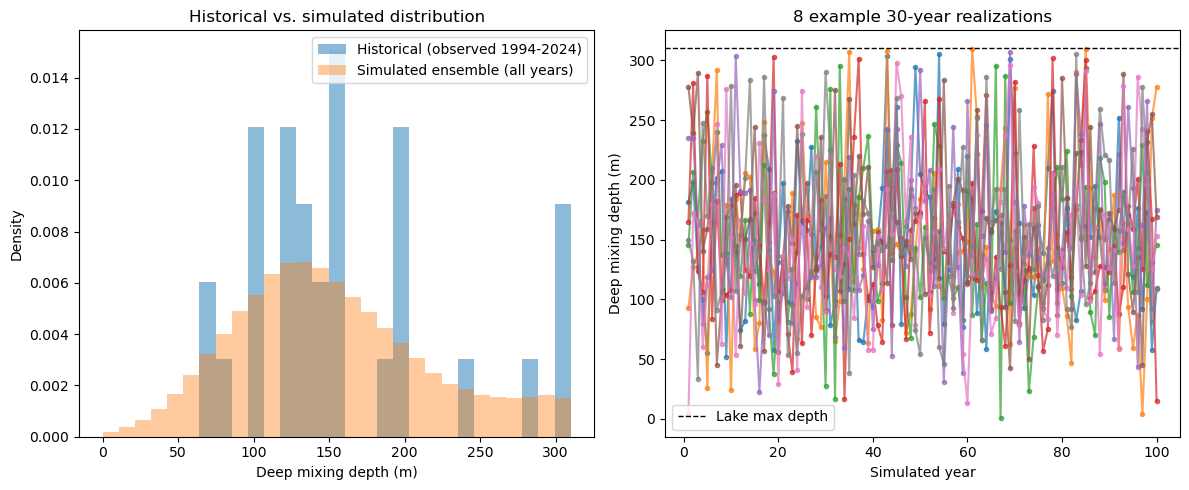

In [9]:
plot_diagnostics(historical.values, simulations)

## Save results

In [10]:
sim_df = pd.DataFrame(
    simulations,
    index=[f"realization_{i+1}" for i in range(N_REALIZATIONS)],
    columns=[f"year_{y+1}" for y in range(N_YEARS)],
)
sim_df.to_csv(OUTPUT_CSV)
print(f"Saved simulations to: {OUTPUT_CSV}")
sim_df.head()

Saved simulations to: lake_geneva_deep_mixing_simulations.csv


,year_1,year_2,year_3,year_4,year_5,year_6,year_7,year_8,year_9,year_10,...,year_91,year_92,year_93,year_94,year_95,year_96,year_97,year_98,year_99,year_100
realization_1,181.459511,198.320822,126.643894,100.590266,55.280017,164.705692,201.358805,207.733379,51.754304,183.909750,...,140.063122,252.089747,140.848895,170.468733,118.427778,176.163207,92.065345,173.091865,57.572009,109.082360
realization_2,92.806929,126.802081,138.366460,158.222188,25.352649,206.864438,291.576787,101.479267,179.222868,23.771588,...,187.013182,58.591390,163.682280,93.604835,59.230605,87.122239,3.897253,99.843700,251.416374,277.860815
realization_3,145.494405,206.244579,165.801003,232.587827,256.953145,197.744731,239.742023,136.992213,138.647327,178.021881,...,159.806239,139.341145,189.926820,160.558611,105.883632,143.050690,229.124611,111.596616,131.544553,145.502652
realization_4,165.017867,280.643574,124.024981,105.817964,287.305880,83.863530,181.979805,108.381468,103.603581,107.753693,...,144.474580,87.456899,110.553348,178.201953,158.437470,201.044140,125.334176,240.508182,167.044553,14.849475
realization_5,235.379349,235.040376,162.241486,79.022418,118.607918,124.137325,198.172938,228.869579,134.181401,101.718623,...,66.347119,221.392655,146.954993,261.077222,193.285461,43.292655,161.770047,265.989182,91.718264,174.957712


## Alternative scenario A — Constant deep mixing at the historical mean

This scenario assumes deep mixing happens at the **same depth every
single year** (the historical mean depth), with no year-to-year
variability at all. Because there's no randomness, running 1000
realizations would just produce 1000 identical rows — so we compute it
once. To stay compatible with the rest of the workflow (and with any
downstream code built around the earlier CSV), the output is still saved
with the **same structure**: rows = realizations, columns = `year_1` …
`year_30` — just with a single row instead of 1000.

In [11]:
CONSTANT_SCENARIO_CSV = "lake_geneva_deep_mixing_constant_scenario.csv"


def build_constant_scenario(depth, n_years):
    """Deterministic scenario: the same depth every year."""
    return np.full(n_years, depth)


MEAN_DEPTH = historical.values.mean()
constant_scenario = build_constant_scenario(MEAN_DEPTH, N_YEARS)

constant_scenario_df = pd.DataFrame(
    constant_scenario.reshape(1, -1),
    index=["realization_1"],
    columns=[f"year_{y+1}" for y in range(N_YEARS)],
)
constant_scenario_df.to_csv(CONSTANT_SCENARIO_CSV)

print(f"Constant deep mixing depth used: {MEAN_DEPTH:.1f} m")
print(f"Saved to: {CONSTANT_SCENARIO_CSV}")
constant_scenario_df

Constant deep mixing depth used: 161.3 m
Saved to: lake_geneva_deep_mixing_constant_scenario.csv


,year_1,year_2,year_3,year_4,year_5,year_6,year_7,year_8,year_9,year_10,...,year_91,year_92,year_93,year_94,year_95,year_96,year_97,year_98,year_99,year_100
realization_1,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,...,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323


## Alternative scenario B — Periodic deep mixing every N years

This scenario assumes a **full/deep mixing event every `N` years**
(`N` is configurable via `DEEP_MIXING_INTERVAL_YEARS` below — set it to
whatever periodicity you want to test, e.g. 5, 10, 15 years), with the
constant mean depth from scenario A used for every other ("quiet") year
in between.

The depth used for the periodic deep-mixing event itself is taken as the
**average of historical years that reached near-full overturn**
(≥ 90% of the lake's max depth) — i.e. a realistic "deep mixing" value
grounded in your actual observations, rather than an arbitrary constant.

Like scenario A, this is fully deterministic (no randomness), so a
single realization is computed and saved in the same row/column format
as before.

In [12]:
PERIODIC_SCENARIO_CSV = "lake_geneva_deep_mixing_periodic_scenario.csv"

# <-- Set the periodicity here (years between deep-mixing events)
DEEP_MIXING_INTERVAL_YEARS = 10

# Representative "deep mixing" depth: mean of historical years that
# reached near-full overturn (>=90% of max lake depth)
deep_years_mask = historical.values >= 0.9 * LAKE_MAX_DEPTH_M
DEEP_MIXING_DEPTH = (
    historical.values[deep_years_mask].mean() if deep_years_mask.any() else LAKE_MAX_DEPTH_M
)
BACKGROUND_DEPTH = MEAN_DEPTH  # same constant depth as scenario A for "quiet" years


def build_periodic_scenario(interval, deep_depth, background_depth, n_years):
    """Deterministic scenario: deep mixing every `interval` years,
    background (mean) depth otherwise."""
    years = np.arange(1, n_years + 1)
    return np.where(years % interval == 0, deep_depth, background_depth)


periodic_scenario = build_periodic_scenario(
    DEEP_MIXING_INTERVAL_YEARS, DEEP_MIXING_DEPTH, BACKGROUND_DEPTH, N_YEARS
)

periodic_scenario_df = pd.DataFrame(
    periodic_scenario.reshape(1, -1),
    index=["realization_1"],
    columns=[f"year_{y+1}" for y in range(N_YEARS)],
)
periodic_scenario_df.to_csv(PERIODIC_SCENARIO_CSV)

print(f"Deep-mixing interval: every {DEEP_MIXING_INTERVAL_YEARS} years")
print(f"Deep-mixing event depth: {DEEP_MIXING_DEPTH:.1f} m")
print(f"Background depth (other years): {BACKGROUND_DEPTH:.1f} m")
print(f"Saved to: {PERIODIC_SCENARIO_CSV}")
periodic_scenario_df

Deep-mixing interval: every 10 years
Deep-mixing event depth: 302.5 m
Background depth (other years): 161.3 m
Saved to: lake_geneva_deep_mixing_periodic_scenario.csv


,year_1,year_2,year_3,year_4,year_5,year_6,year_7,year_8,year_9,year_10,...,year_91,year_92,year_93,year_94,year_95,year_96,year_97,year_98,year_99,year_100
realization_1,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,302.5,...,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,161.290323,302.5


## Comparing the scenarios

One example stochastic (KDE-based) realization vs. the two deterministic
scenarios, over the same 30-year horizon.

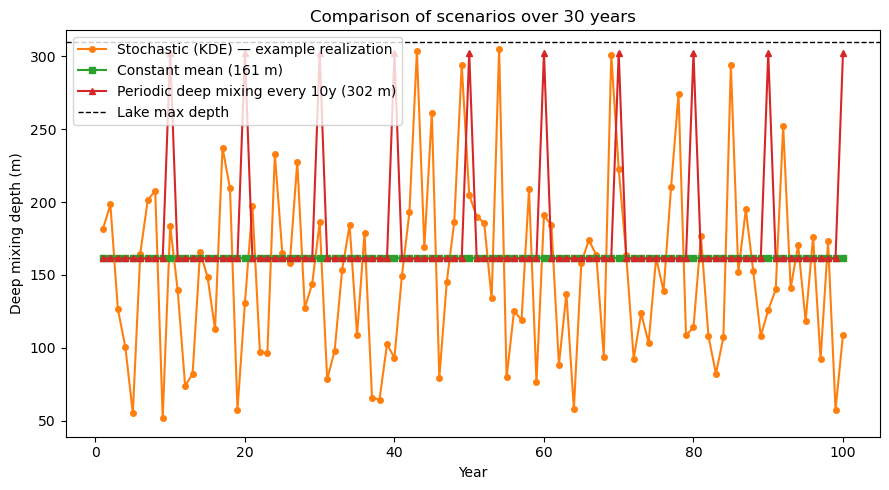

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
years_axis = np.arange(1, N_YEARS + 1)

ax.plot(years_axis, simulations[0], marker="o", markersize=4,
        label="Stochastic (KDE) — example realization", color="tab:orange")
ax.plot(years_axis, constant_scenario, marker="s", markersize=4,
        label=f"Constant mean ({MEAN_DEPTH:.0f} m)", color="tab:green")
ax.plot(years_axis, periodic_scenario, marker="^", markersize=4,
        label=f"Periodic deep mixing every {DEEP_MIXING_INTERVAL_YEARS}y "
              f"({DEEP_MIXING_DEPTH:.0f} m)", color="tab:red")
ax.axhline(LAKE_MAX_DEPTH_M, color="k", linestyle="--", linewidth=1,
           label="Lake max depth")

ax.set_xlabel("Year")
ax.set_ylabel("Deep mixing depth (m)")
ax.set_title("Comparison of scenarios over 30 years")
ax.legend()
fig.tight_layout()
plt.show()